# Decision Tree Classifier with Employee Attrition Dataset

In this notebook, we will build a decision tree classifier using the scikit-learn library. We will use a hypothetical employee attrition dataset for this example.

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## Load and Explore the Dataset

In [2]:
df = pd.read_csv('employee_attrition_small.csv')
print('Shape:', df.shape)
df.head()

Shape: (1470, 16)


,Age,Attrition,BusinessTravel,DailyRate,Department,EducationField,Gender,HourlyRate,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,TotalWorkingYears
0,41,Yes,Travel_Rarely,1102,Sales,Life Sciences,Female,94,Sales Executive,4,Single,5993,19479,8,Yes,8
1,49,No,Travel_Frequently,279,Research & Development,Life Sciences,Male,61,Research Scientist,2,Married,5130,24907,1,No,10
2,37,Yes,Travel_Rarely,1373,Research & Development,Other,Male,92,Laboratory Technician,3,Single,2090,2396,6,Yes,7
3,33,No,Travel_Frequently,1392,Research & Development,Life Sciences,Female,56,Research Scientist,3,Married,2909,23159,1,Yes,8
4,27,No,Travel_Rarely,591,Research & Development,Medical,Male,40,Laboratory Technician,2,Married,3468,16632,9,No,6


## Preprocess the Data

We need to convert categorical text columns to numbers before feeding them to the model.

> **Note:** `JobSatisfaction` is already numeric (1–4) so it is left as-is.

In [3]:
print('Missing values:', df.isnull().sum().sum())

# Store one encoder per column so we can use them later for prediction
encoders = {}
columns_to_encode = ['BusinessTravel', 'Department', 'EducationField',
                     'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

for col in columns_to_encode:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

df.head()

Missing values: 0
BusinessTravel: {'Non-Travel': np.int64(0), 'Travel_Frequently': np.int64(1), 'Travel_Rarely': np.int64(2)}
Department: {'Human Resources': np.int64(0), 'Research & Development': np.int64(1), 'Sales': np.int64(2)}
EducationField: {'Human Resources': np.int64(0), 'Life Sciences': np.int64(1), 'Marketing': np.int64(2), 'Medical': np.int64(3), 'Other': np.int64(4), 'Technical Degree': np.int64(5)}
Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
JobRole: {'Healthcare Representative': np.int64(0), 'Human Resources': np.int64(1), 'Laboratory Technician': np.int64(2), 'Manager': np.int64(3), 'Manufacturing Director': np.int64(4), 'Research Director': np.int64(5), 'Research Scientist': np.int64(6), 'Sales Executive': np.int64(7), 'Sales Representative': np.int64(8)}
MaritalStatus: {'Divorced': np.int64(0), 'Married': np.int64(1), 'Single': np.int64(2)}
OverTime: {'No': np.int64(0), 'Yes': np.int64(1)}


,Age,Attrition,BusinessTravel,DailyRate,Department,EducationField,Gender,HourlyRate,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,TotalWorkingYears
0,41,Yes,2,1102,2,1,0,94,7,4,2,5993,19479,8,1,8
1,49,No,1,279,1,1,1,61,6,2,1,5130,24907,1,0,10
2,37,Yes,2,1373,1,4,1,92,2,3,2,2090,2396,6,1,7
3,33,No,1,1392,1,1,0,56,6,3,1,2909,23159,1,1,8
4,27,No,2,591,1,3,1,40,2,2,1,3468,16632,9,0,6


## Split the Dataset

In [4]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train:', len(X_train), '  Test:', len(X_test))

Train: 1176   Test: 294


## Train the Decision Tree Model

> **Note:** Keep `max_depth` no greater than 3 to avoid an unreadable tree.

In [5]:
dt_classifier = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_classifier.fit(X_train, y_train)

y_pred = dt_classifier.predict(X_test)

print(f'Decision Tree Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%')

Decision Tree Accuracy: 86.73%


## Evaluate the Model

Accuracy alone can be misleading when classes are imbalanced. The confusion matrix shows how many employees who actually left (`Yes`) were correctly identified — the **false negatives** (bottom-left cell) represent missed resignations.

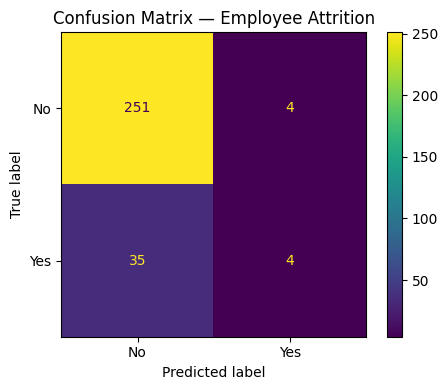

In [6]:
cm = confusion_matrix(y_test, y_pred, labels=['No', 'Yes'])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes']).plot(ax=ax)
ax.set_title('Confusion Matrix — Employee Attrition')
plt.tight_layout()
plt.show()

## Visualize the Decision Tree

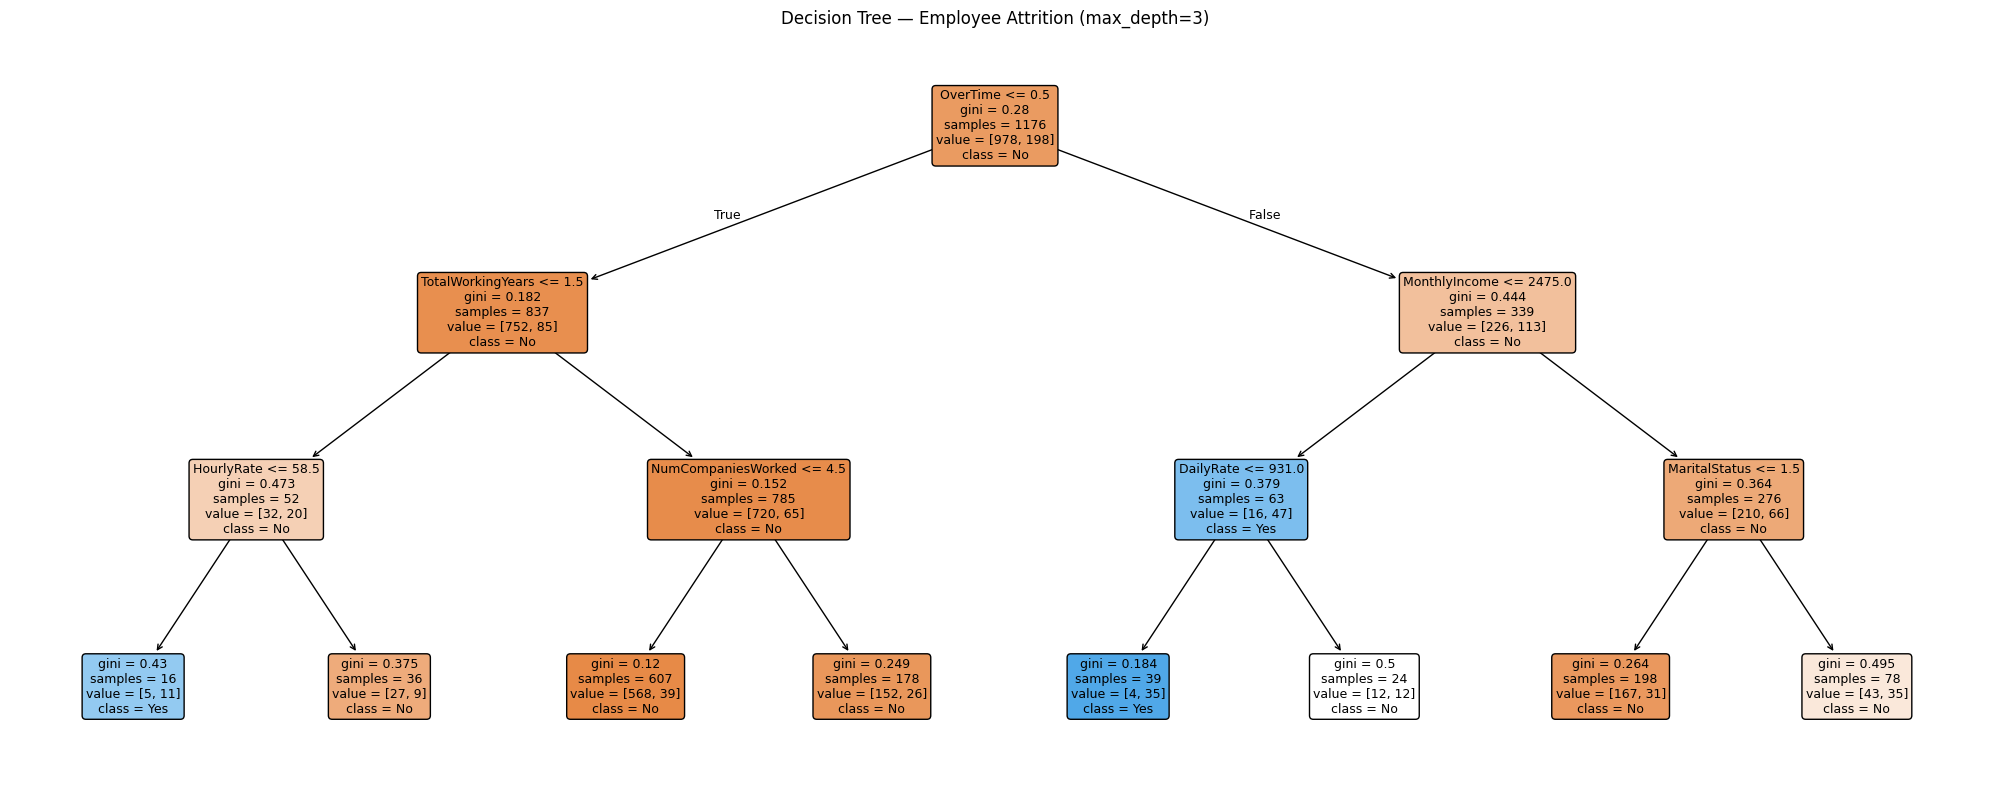

In [7]:
plt.figure(figsize=(20, 8))
plot_tree(
    dt_classifier,
    feature_names=X.columns,
    class_names=dt_classifier.classes_.tolist(),
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Decision Tree — Employee Attrition (max_depth=3)')
plt.tight_layout()
plt.show()

## Predict for a New Employee

Use the same encoders to convert human-readable values before predicting.

In [8]:
new_employee = pd.DataFrame([{
    'Age': 36,
    'BusinessTravel': encoders['BusinessTravel'].transform(['Travel_Rarely'])[0],
    'DailyRate': 800,
    'Department': encoders['Department'].transform(['Research & Development'])[0],
    'EducationField': encoders['EducationField'].transform(['Life Sciences'])[0],
    'Gender': encoders['Gender'].transform(['Male'])[0],
    'HourlyRate': 65,
    'JobRole': encoders['JobRole'].transform(['Research Scientist'])[0],
    'JobSatisfaction': 3,
    'MaritalStatus': encoders['MaritalStatus'].transform(['Single'])[0],
    'MonthlyIncome': 6000,
    'MonthlyRate': 15000,
    'NumCompaniesWorked': 3,
    'OverTime': encoders['OverTime'].transform(['Yes'])[0],
    'TotalWorkingYears': 10
}])

prediction = dt_classifier.predict(new_employee)[0]
print('Predicted Attrition:', prediction)

Predicted Attrition: No
